Anomalies Detected

     Order Date  Total amount  Anomaly
54   2011-03-18    28106.7160     True
162  2011-07-25     8341.2900     True
197  2011-09-08    14228.4280     True
207  2011-09-19     9338.6370     True
211  2011-09-23    10662.3370     True
217  2011-09-29     8109.0700     True
251  2011-11-04     6693.7480     True
258  2011-11-11     8114.5480     True
263  2011-11-17    11544.2740     True
265  2011-11-19     7226.0860     True
289  2011-12-14     7641.6580     True
294  2011-12-20     6962.4400     True
353  2012-03-16     7230.2100     True
481  2012-08-24     7194.7750     True
484  2012-08-28     6491.2930     True
501  2012-09-17    11525.0060     True
505  2012-09-21     6982.0580     True
544  2012-11-08    12196.9970     True
566  2012-12-01     7130.5940     True
588  2012-12-24     7484.5660     True
618  2013-02-02     8996.7840     True
642  2013-03-04     7264.4220     True
649  2013-03-11     7879.7340     True
652  2013-03-14     8866.8820     True
683  

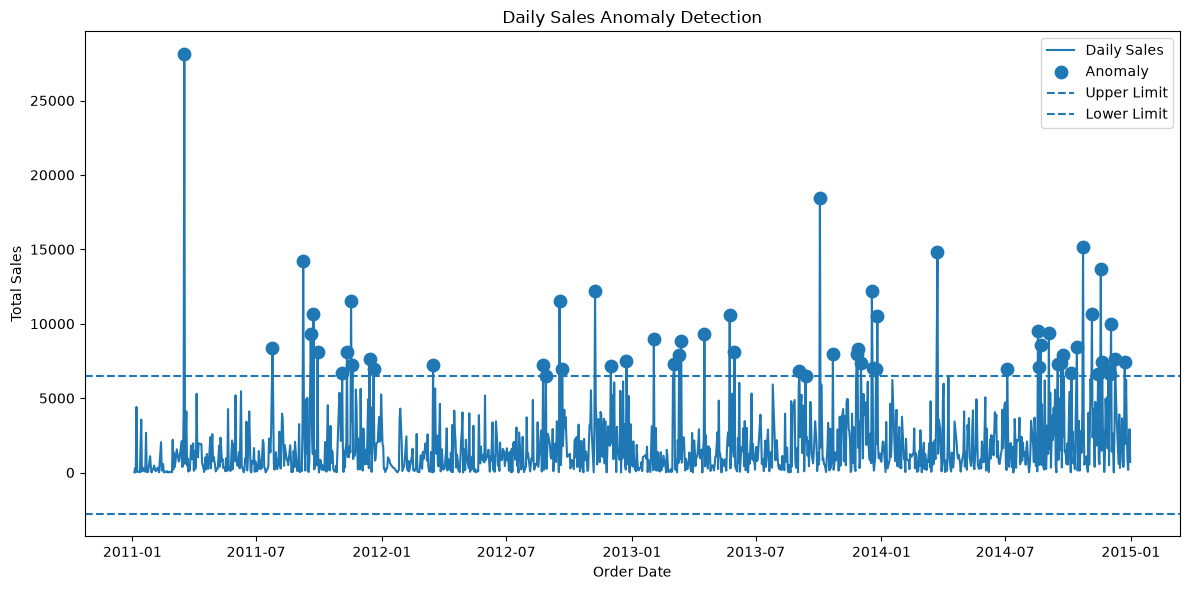


Anomaly detection completed successfully.


In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("cleaned_dataset.csv")

# ------------------------------------------
# Check Required Columns
# ------------------------------------------

required_columns = ["Order Date", "Total amount"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"{col} column not found in dataset.")

# ------------------------------------------
# Convert Order Date
# ------------------------------------------

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

# ------------------------------------------
# Daily Sales
# ------------------------------------------

daily_sales = (
    df.groupby("Order Date")["Total amount"]
      .sum()
      .reset_index()
)

# ------------------------------------------
# Calculate Mean and Standard Deviation
# ------------------------------------------

mean_sales = daily_sales["Total amount"].mean()
std_sales = daily_sales["Total amount"].std()

# ------------------------------------------
# Define Anomaly Limits
# ------------------------------------------

upper_limit = mean_sales + (2 * std_sales)
lower_limit = mean_sales - (2 * std_sales)

# ------------------------------------------
# Detect Anomalies
# ------------------------------------------

daily_sales["Anomaly"] = (
    (daily_sales["Total amount"] > upper_limit) |
    (daily_sales["Total amount"] < lower_limit)
)

# ------------------------------------------
# Display Results
# ------------------------------------------

print("Anomalies Detected\n")

print(daily_sales[daily_sales["Anomaly"]])

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Total amount"],
    label="Daily Sales"
)

anomalies = daily_sales[daily_sales["Anomaly"]]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Total amount"],
    marker="o",
    s=80,
    label="Anomaly"
)

plt.axhline(
    upper_limit,
    linestyle="--",
    label="Upper Limit"
)

plt.axhline(
    lower_limit,
    linestyle="--",
    label="Lower Limit"
)

plt.title("Daily Sales Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------
# Save Output
# ------------------------------------------

daily_sales.to_csv(
    "anomaly_detection_results.csv",
    index=False
)

print("\nAnomaly detection completed successfully.")